# 04 — CrowdEnv: Gymnasium Training Environment

This notebook demonstrates the full `CrowdEnv` Gymnasium wrapper:

1. **Environment creation** with configurable geometry tiers, agent counts, and reward settings
2. **Reset**: procedural geometry generation → agent spawning → solvability verification → observation construction
3. **Step loop**: action interpretation → physics integration → collision forces → rewards
4. **Multi-tier training**: randomising geometry complexity across episodes
5. **Visualising** episodes using the crowdrl-env visualiser

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from crowdrl_env import CrowdEnv, CrowdEnvConfig, GeometryConfig, GeometryTier, SpawnConfig, RewardConfig
from crowdrl_env.solvability import SolvabilityMode
from crowdrl_env.visualiser import visualise_world_state, plot_geometry, plot_navmesh, plot_agents
from crowdrl_core import ObsConfig, ActionConfig, RaycastConfig

## 1. Basic environment: Tier 0 open field

In [2]:
config = CrowdEnvConfig(
    geometry=GeometryConfig(tier=GeometryTier.TIER_0, min_side=10.0, max_side=15.0),
    spawn=SpawnConfig(n_agents_range=(5, 10)),
    obs=ObsConfig(use_navmesh=True),
    max_steps=200,
)

env = CrowdEnv(config=config, seed=42)
obs, info = env.reset()

print(f"Agents: {env.n_agents}")
print(f"Observation shape: {obs.shape}  (obs_dim={config.obs.obs_dim})")
print(f"Action dim: {config.action.action_dim}")
print(f"Geometry: {info['geometry_tier']} / {info['geometry_shape']}")

Agents: 7
Observation shape: (7, 82)  (obs_dim=82)
Action dim: 4
Geometry: TIER_0 / convex


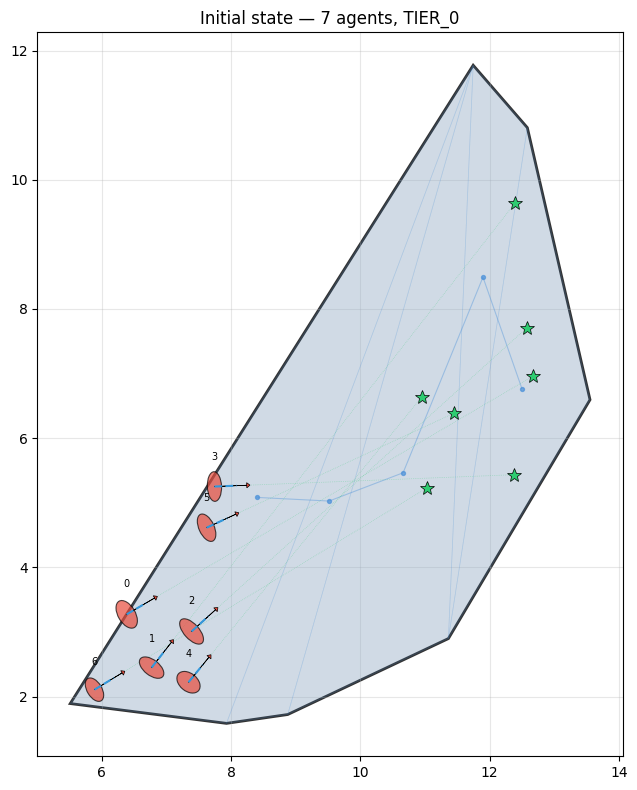

In [3]:
# Visualise the initial state
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
visualise_world_state(env._world, ax=ax, show_navmesh=True)
ax.set_title(f"Initial state — {env.n_agents} agents, {info['geometry_tier']}")
plt.tight_layout()
plt.show()

## 2. Running an episode with random actions

In [4]:
rng = np.random.default_rng(0)
obs, info = env.reset(seed=42)

total_rewards = np.zeros(env.n_agents)
episode_length = 0
n_goals_reached = 0

for step in range(config.max_steps):
    # Random actions (in practice, a policy network would produce these)
    actions = rng.uniform(-1, 1, (env.n_agents, config.action.action_dim))
    obs, rewards, terminated, truncated, info = env.step(actions)
    
    total_rewards += rewards
    n_goals_reached += int(np.sum(terminated))
    episode_length = step + 1
    
    if info["episode_over"]:
        break

print(f"Episode length: {episode_length} steps")
print(f"Goals reached: {n_goals_reached}/{env.n_agents}")
print(f"Mean total reward: {total_rewards.mean():.2f}")
print(f"Min/Max reward: {total_rewards.min():.2f} / {total_rewards.max():.2f}")

Episode length: 200 steps
Goals reached: 2/7
Mean total reward: -277.24
Min/Max reward: -516.60 / -65.45


## 3. Tier 1 — Corridor with bottleneck

Agents: 7, Geometry: bottleneck


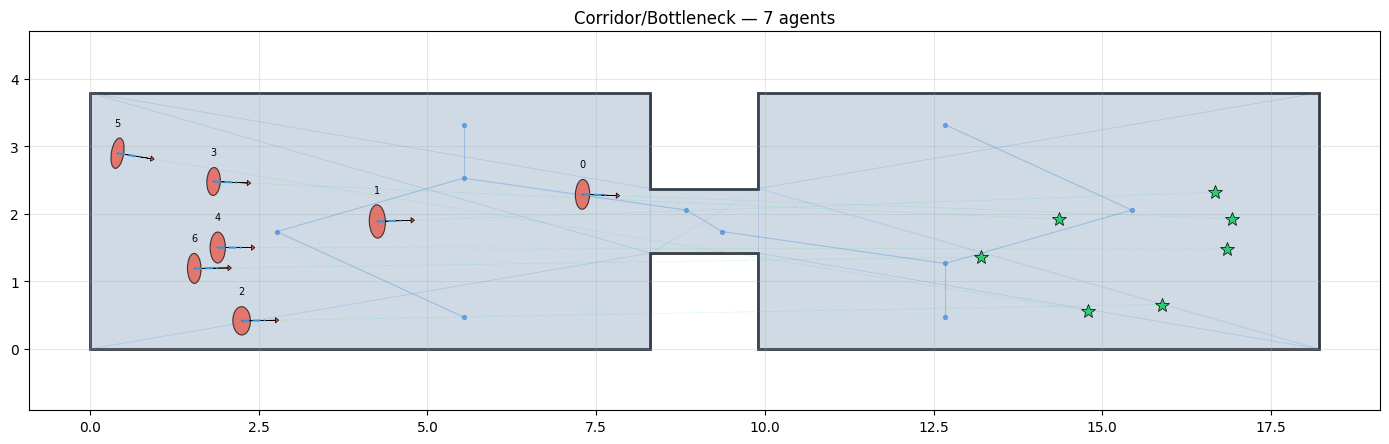

In [5]:
corridor_config = CrowdEnvConfig(
    geometry=GeometryConfig(
        tier=GeometryTier.TIER_1,
        corridor_width_range=(2.0, 4.0),
        corridor_length_range=(12.0, 20.0),
        bottleneck_aperture_range=(0.8, 1.5),
    ),
    spawn=SpawnConfig(n_agents_range=(5, 12), min_spawn_separation=0.4),
    solvability_mode=SolvabilityMode.PRUNE,
    obs=ObsConfig(use_navmesh=True),
    max_steps=300,
)

corridor_env = CrowdEnv(config=corridor_config, seed=7)
obs, info = corridor_env.reset()

print(f"Agents: {corridor_env.n_agents}, Geometry: {info['geometry_shape']}")

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
visualise_world_state(corridor_env._world, ax=ax, show_navmesh=True)
ax.set_title(f"Corridor/Bottleneck — {corridor_env.n_agents} agents")
plt.tight_layout()
plt.show()

## 4. Multi-tier randomisation

During training, the curriculum randomly selects geometry tiers per episode.
This demonstrates that the environment can handle different tiers seamlessly.

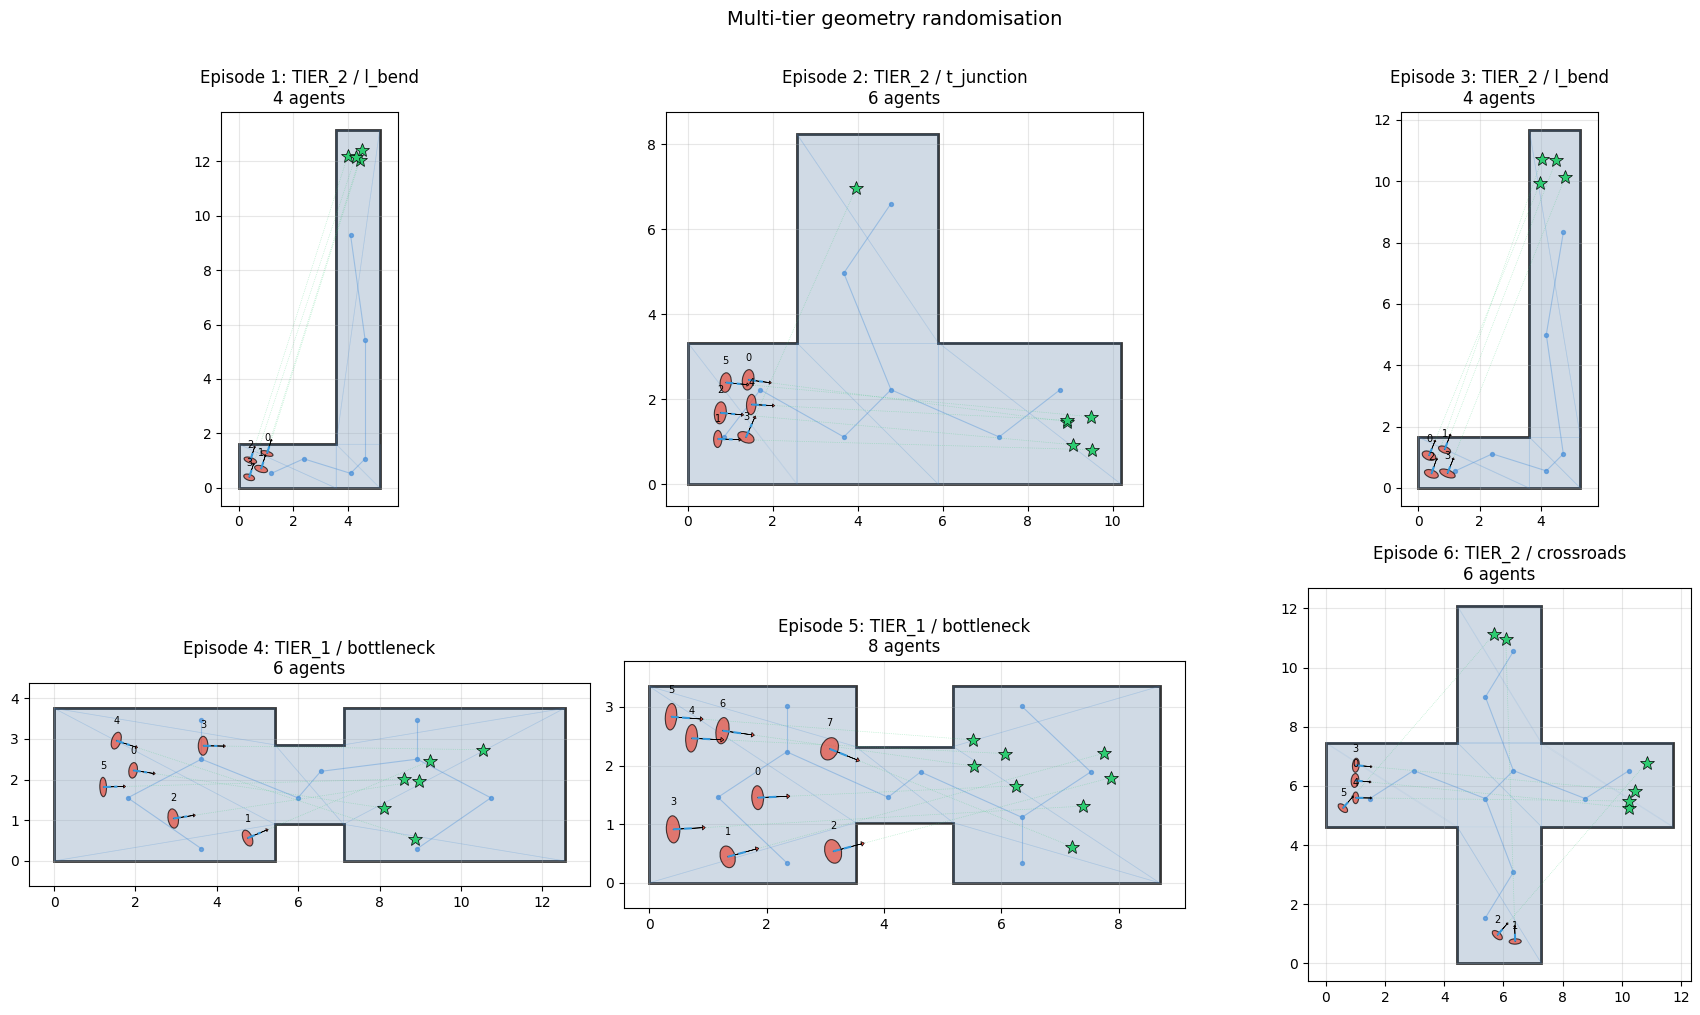

In [6]:
multi_config = CrowdEnvConfig(
    geometry_tiers=[GeometryTier.TIER_0, GeometryTier.TIER_1, GeometryTier.TIER_2],
    spawn=SpawnConfig(n_agents_range=(4, 8)),
    obs=ObsConfig(use_navmesh=True),
    max_steps=100,
)

multi_env = CrowdEnv(config=multi_config, seed=0)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    obs, info = multi_env.reset()
    visualise_world_state(multi_env._world, ax=ax, show_navmesh=True)
    ax.set_title(f"Episode {i+1}: {info['geometry_tier']} / {info['geometry_shape']}\n"
                 f"{multi_env.n_agents} agents")

plt.suptitle("Multi-tier geometry randomisation", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Stepping through with visualisation

Run a short episode and visualise snapshots every N steps.

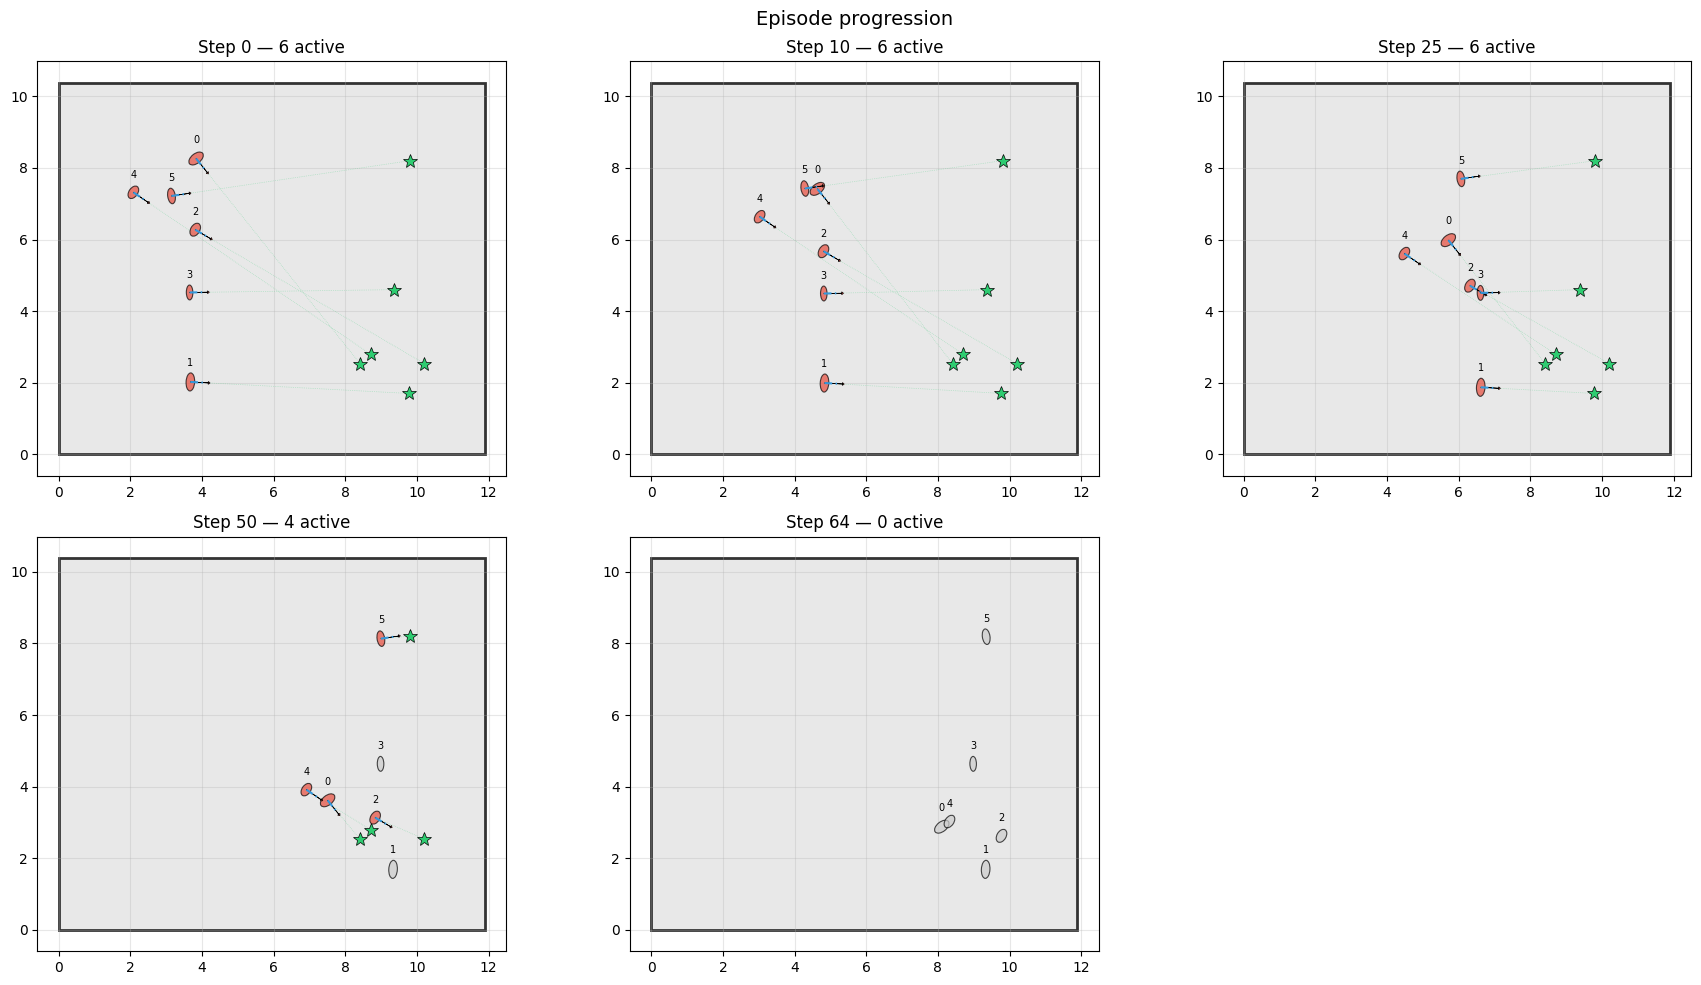

In [7]:
vis_config = CrowdEnvConfig(
    geometry=GeometryConfig(tier=GeometryTier.TIER_0, min_side=10.0, max_side=12.0),
    spawn=SpawnConfig(n_agents_range=(6, 6)),
    obs=ObsConfig(use_navmesh=True),
    reward=RewardConfig(use_smoothness=True),
    max_steps=100,
    dt=0.1,
)

vis_env = CrowdEnv(config=vis_config, seed=12)
obs, info = vis_env.reset()
rng = np.random.default_rng(42)

snapshot_steps = [0, 10, 25, 50, 75, 99]
snapshots = []

# Capture initial state
import copy
snapshots.append((0, copy.deepcopy(vis_env._world), info.copy()))

for step in range(1, vis_config.max_steps):
    # Biased actions: mostly forward with some randomness
    actions = np.zeros((vis_env.n_agents, vis_config.action.action_dim))
    actions[:, 0] = 0.6  # Moderate speed
    actions[:, 1] = rng.uniform(-0.3, 0.3, vis_env.n_agents)  # Slight heading variation
    
    obs, rewards, terminated, truncated, info = vis_env.step(actions)
    
    if step in snapshot_steps:
        snapshots.append((step, copy.deepcopy(vis_env._world), info.copy()))
    
    if info["episode_over"]:
        snapshots.append((step, copy.deepcopy(vis_env._world), info.copy()))
        break

# Plot snapshots
n_snaps = len(snapshots)
cols = min(3, n_snaps)
rows = (n_snaps + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
if n_snaps == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, (step, world, step_info) in enumerate(snapshots):
    if idx < len(axes):
        ax = axes[idx]
        plot_geometry(world.walkable_polygon, ax=ax)
        plot_agents(world, ax=ax)
        n_active = int(np.sum(world.active_mask)) if world.active_mask is not None else world.n_agents
        ax.set_title(f"Step {step} — {n_active} active")

# Hide unused axes
for idx in range(n_snaps, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Episode progression", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Reward analysis

Compare reward distributions between random actions and simple goal-seeking heuristic.

C:\Users\Fabian\AppData\Local\Temp\ipykernel_33156\1514135175.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([random_rewards, forward_rewards], labels=["Random", "Forward heuristic"])


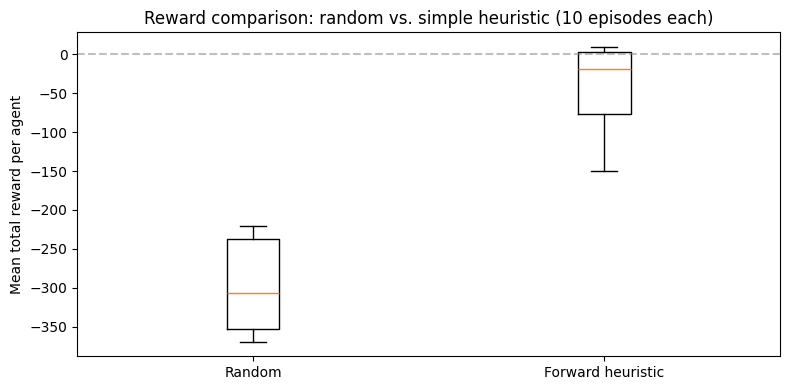

Random:  mean=-298.42, std=56.30
Forward: mean=-42.62, std=52.60


In [9]:
def run_episode(env, policy_fn, seed=0):
    """Run one episode, return per-agent total rewards."""
    obs, _ = env.reset(seed=seed)
    total_r = np.zeros(env.n_agents)
    for _ in range(env.config.max_steps):
        actions = policy_fn(obs, env.n_agents, env.config.action.action_dim)
        obs, rewards, terminated, truncated, info = env.step(actions)
        total_r += rewards
        if info["episode_over"]:
            break
    return total_r


def random_policy(obs, n, adim):
    return np.random.default_rng().uniform(-1, 1, (n, adim))


def forward_policy(obs, n, adim):
    """Simple heuristic: move forward at moderate speed."""
    actions = np.zeros((n, adim))
    actions[:, 0] = 0.5  # Moderate forward speed
    return actions


eval_config = CrowdEnvConfig(
    geometry=GeometryConfig(tier=GeometryTier.TIER_0, min_side=10.0, max_side=12.0),
    spawn=SpawnConfig(n_agents_range=(8, 8)),
    reward=RewardConfig(use_smoothness=True),
    max_steps=200,
)
eval_env = CrowdEnv(config=eval_config)

random_rewards = [run_episode(eval_env, random_policy, seed=s).mean() for s in range(10)]
forward_rewards = [run_episode(eval_env, forward_policy, seed=s).mean() for s in range(10)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([random_rewards, forward_rewards], labels=["Random", "Forward heuristic"])
ax.set_ylabel("Mean total reward per agent")
ax.set_title("Reward comparison: random vs. simple heuristic (10 episodes each)")
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Random:  mean={np.mean(random_rewards):.2f}, std={np.std(random_rewards):.2f}")
print(f"Forward: mean={np.mean(forward_rewards):.2f}, std={np.std(forward_rewards):.2f}")

## 7. Gymnasium API compatibility

Verify the environment follows the Gymnasium interface.

In [10]:
env = CrowdEnv(config=CrowdEnvConfig(
    geometry=GeometryConfig(tier=GeometryTier.TIER_0, min_side=8.0, max_side=10.0),
    spawn=SpawnConfig(n_agents_range=(3, 5)),
    max_steps=10,
), seed=42)

print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Obs dim:           {env.observation_space.shape}")
print(f"Action dim:        {env.action_space.shape}")

# Check that obs/actions are within declared spaces
obs, _ = env.reset()
for i in range(env.n_agents):
    assert env.observation_space.contains(obs[i]), f"Obs {i} outside space"

sample_action = env.action_space.sample()
assert env.action_space.contains(sample_action)
print(f"\nSample action: {sample_action}")
print("All checks passed.")

Observation space: Box(-inf, inf, (79,), float64)
Action space:      Box(-1.0, 1.0, (4,), float64)
Obs dim:           (79,)
Action dim:        (4,)

Sample action: [-0.2815299  -0.50883599 -0.33711096 -0.30563309]
All checks passed.
